**Table of contents**<a id='toc0_'></a>    
- [Data Mining Lab 2 - Phase 1](#toc1_)    
  - [Summarized Table of Contents](#toc1_1_)    
  - [Before Starting](#toc1_2_)    
  - [Introduction](#toc1_3_)    
  - [**1. Data Preparation**](#toc1_4_)    
  - [**1.1 Load data**](#toc1_5_)    
        - [**>>> Exercise 1 (Take home):**](#toc1_5_1_1_1_)    
    - [**1.2 Save data**](#toc1_5_2_)    
    - [**1.3 Exploratory data analysis (EDA)**](#toc1_5_3_)    
  - [**2. Feature engineering**](#toc1_6_)    
    - [Using Bag of Words](#toc1_6_1_)    
        - [**>>> Exercise 2 (Take home):**](#toc1_6_1_1_1_)    
  - [**3. Model**](#toc1_7_)    
    - [**3.1 Decision Trees**](#toc1_7_1_)    
  - [**4. Results Evaluation**](#toc1_8_)    
        - [**>>> Exercise 3 (Take home):**](#toc1_8_1_1_1_)    
        - [**>>> Exercise 4 (Take home):**](#toc1_8_1_1_2_)    
        - [**>>> Exercise 5 (Take home):**](#toc1_8_1_1_3_)    
  - [**5. Other things you can try**](#toc1_9_)    
  - [**6. Deep Learning**](#toc1_10_)    
    - [**6.1 Prepare data (X, y)**](#toc1_10_1_)    
    - [**6.2 Deal with categorical label (y)**](#toc1_10_2_)    
    - [**6.3 Build model**](#toc1_10_3_)    
    - [**6.4 Train**](#toc1_10_4_)    
    - [**6.5 Predict on testing data**](#toc1_10_5_)    
        - [**>>> Exercise 6 (Take home):**](#toc1_10_5_1_1_)    
    - [Note](#toc1_10_6_)    
    - [More Information for your reference](#toc1_10_7_)    
  - [**7. Word2Vector**](#toc1_11_)    
    - [**7.1 Prepare training corpus**](#toc1_11_1_)    
    - [**7.2 Training our model**](#toc1_11_2_)    
    - [**7.3 Generating word vector (embeddings)**](#toc1_11_3_)    
    - [**7.4 Using a pre-trained w2v model**](#toc1_11_4_)    
      - [(1) Download model by yourself](#toc1_11_4_1_)    
      - [(2) Using gensim api](#toc1_11_4_2_)    
    - [**7.5 king + woman - man = ?**](#toc1_11_5_)    
        - [**>>> Exercise 7 (Take home):**](#toc1_11_5_1_1_)    
  - [**8. Clustering: k-means**](#toc1_12_)    
      - [Basic concept](#toc1_12_1_1_)    
  - [**9. High-dimension Visualization: t-SNE and UMAP**](#toc1_13_)    
    - [**9.1 Prepare visualizing target**](#toc1_13_1_)    
    - [**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc1_13_2_)    
        - [**>>> Exercise 8 (Take home):**](#toc1_13_2_1_1_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_2_'></a>[Before Starting](#toc0_)

**Make sure you have installed all the required libraries and you have the environment ready to run this lab.**
    

# <a id='toc1_'></a>[Data Mining Lab 2 - Phase 1](#toc0_)
In this lab's phase 1 session we will focus on the use of Neural Word Embeddings

## <a id='toc1_1_'></a>[Summarized Table of Contents](#toc0_)
- **Phase 1:**
1. Data preparation
2. Feature engineering
3. Model
4. Results evaluation
5. Other things you could try
6. Deep Learning
7. Word to Vector
8. Clustering
9. High-dimension Visualization


---
## <a id='toc1_3_'></a>[Introduction](#toc0_)

**Dataset:** [SemEval 2017 Task](https://competitions.codalab.org/competitions/16380)

**Task:** Classify text data into 4 different emotions using word embeddings and other deep information retrieval approaches.

![pic0.png](./pics/pic0.png)

In [21]:
# ===========================================
# ✅ SAFE IMPORTS BLOCK (run at top of notebook)
# ===========================================

# Core libraries
import pandas as pd
import numpy as np
import nltk
import warnings
warnings.filterwarnings("ignore")

# Machine Learning & NLP
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Deep Learning
import keras
from keras.models import Model
from keras.layers import Input, Dense, ReLU, Softmax

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Word Embeddings
from gensim.models import Word2Vec, KeyedVectors

# Tokenizer
nltk.download('punkt')

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [1]:
!pip install pandas numpy matplotlib seaborn nltk scikit-learn gensim wordcloud umap-learn tensorflow keras


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 72.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 44.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.

In [4]:
import pandas as pd


In [5]:
# Create folders to store the data
!mkdir -p data/semeval/train
!mkdir -p data/semeval/dev

# Download training data files
!wget -O data/semeval/train/anger-ratings-0to1.train.txt https://raw.githubusercontent.com/Slee08-tech/DM2025-Lab2-Exercise/main/data/semeval/train/anger-ratings-0to1.train.txt
!wget -O data/semeval/train/sadness-ratings-0to1.train.txt https://raw.githubusercontent.com/Slee08-tech/DM2025-Lab2-Exercise/main/data/semeval/train/sadness-ratings-0to1.train.txt
!wget -O data/semeval/train/fear-ratings-0to1.train.txt https://raw.githubusercontent.com/Slee08-tech/DM2025-Lab2-Exercise/main/data/semeval/train/fear-ratings-0to1.train.txt
!wget -O data/semeval/train/joy-ratings-0to1.train.txt https://raw.githubusercontent.com/Slee08-tech/DM2025-Lab2-Exercise/main/data/semeval/train/joy-ratings-0to1.train.txt

# Download testing data files
!wget -O data/semeval/dev/anger-ratings-0to1.dev.gold.txt https://raw.githubusercontent.com/Slee08-tech/DM2025-Lab2-Exercise/main/data/semeval/dev/anger-ratings-0to1.dev.gold.txt
!wget -O data/semeval/dev/sadness-ratings-0to1.dev.gold.txt https://raw.githubusercontent.com/Slee08-tech/DM2025-Lab2-Exercise/main/data/semeval/dev/sadness-ratings-0to1.dev.gold.txt
!wget -O data/semeval/dev/fear-ratings-0to1.dev.gold.txt https://raw.githubusercontent.com/Slee08-tech/DM2025-Lab2-Exercise/main/data/semeval/dev/fear-ratings-0to1.dev.gold.txt
!wget -O data/semeval/dev/joy-ratings-0to1.dev.gold.txt https://raw.githubusercontent.com/Slee08-tech/DM2025-Lab2-Exercise/main/data/semeval/dev/joy-ratings-0to1.dev.gold.txt


--2025-11-01 01:37:57--  https://raw.githubusercontent.com/Slee08-tech/DM2025-Lab2-Exercise/main/data/semeval/train/anger-ratings-0to1.train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 95686 (93K) [text/plain]
Saving to: ‘data/semeval/train/anger-ratings-0to1.train.txt’

data/semeval/train/ 100%[===================>]  93.44K  --.-KB/s    in 0.01s   

2025-11-01 01:37:58 (6.42 MB/s) - ‘data/semeval/train/anger-ratings-0to1.train.txt’ saved [95686/95686]

--2025-11-01 01:37:58--  https://raw.githubusercontent.com/Slee08-tech/DM2025-Lab2-Exercise/main/data/semeval/train/sadness-ratings-0to1.train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubuserconte

In [6]:
import os
print(os.listdir("data/semeval/train"))
print(os.listdir("data/semeval/dev"))


['sadness-ratings-0to1.train.txt', 'anger-ratings-0to1.train.txt', 'joy-ratings-0to1.train.txt', 'fear-ratings-0to1.train.txt']
['joy-ratings-0to1.dev.gold.txt', 'anger-ratings-0to1.dev.gold.txt', 'sadness-ratings-0to1.dev.gold.txt', 'fear-ratings-0to1.dev.gold.txt']


In [7]:
import pandas as pd

# ---------- TRAINING DATA ----------
anger_train = pd.read_csv("data/semeval/train/anger-ratings-0to1.train.txt",
                          sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_train = pd.read_csv("data/semeval/train/sadness-ratings-0to1.train.txt",
                            sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_train = pd.read_csv("data/semeval/train/fear-ratings-0to1.train.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_train = pd.read_csv("data/semeval/train/joy-ratings-0to1.train.txt",
                        sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# ---------- TESTING DATA ----------
anger_test = pd.read_csv("data/semeval/dev/anger-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_test = pd.read_csv("data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",
                           sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_test = pd.read_csv("data/semeval/dev/fear-ratings-0to1.dev.gold.txt",
                        sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_test = pd.read_csv("data/semeval/dev/joy-ratings-0to1.dev.gold.txt",
                       sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# ---------- COMBINE & SHUFFLE ----------
train_df = pd.concat([anger_train, sadness_train, fear_train, joy_train], ignore_index=True)
test_df  = pd.concat([anger_test, sadness_test, fear_test, joy_test], ignore_index=True)

train_df = train_df.sample(frac=1, random_state=42)
test_df  = test_df.sample(frac=1, random_state=42)

print("✅ Training shape:", train_df.shape)
print("✅ Testing shape:", test_df.shape)
train_df.head()


✅ Training shape: (3613, 4)
✅ Testing shape: (347, 4)


,id,text,emotion,intensity
839,10839,Grateful for all the hungry people in my life!...,anger,0.167
2630,20987,@CSTrey4 thanks brotein shake 😈😈😈,fear,0.271
32,10032,I blame the whole season on Natalie! The seaso...,anger,0.792
2398,20755,"I like the commercial where @kohara19, on a ch...",fear,0.396
411,10411,@JasonMillerinDC @realDonaldTrump Prudence sug...,anger,0.500


In [8]:
anger_train = pd.read_csv("data/semeval/train/anger-ratings-0to1.train.txt", sep="\t", header=None, names=["id", "text", "emotion", "intensity"])


---
## <a id='toc1_4_'></a>[**1. Data Preparation**](#toc0_)

Before beggining the lab, please make sure to download the [Google News Dataset](https://drive.google.com/file/d/0B7XkCwpI5KDYNlNUTTlSS21pQmM/edit) and place it in a folder named "GoogleNews" in the same directory as this file.

---
## <a id='toc1_5_'></a>[**1.1 Load data**](#toc0_)

We start by loading the csv files into a single pandas dataframe for training and one for testing.

In [ ]:
# combine 4 sub-dataset
train_df = pd.concat([anger_train, fear_train, joy_train, sadness_train], ignore_index=True)

In [ ]:
### testing data
anger_test = pd.read_csv("data/semeval/dev/anger-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
sadness_test = pd.read_csv("data/semeval/dev/sadness-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
fear_test = pd.read_csv("data/semeval/dev/fear-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])
joy_test = pd.read_csv("data/semeval/dev/joy-ratings-0to1.dev.gold.txt",
                         sep="\t", header=None, names=["id", "text", "emotion", "intensity"])

# combine 4 sub-dataset
test_df = pd.concat([anger_test, fear_test, joy_test, sadness_test], ignore_index=True)
train_df.head()

In [ ]:
# shuffle dataset
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

In [ ]:
print("Shape of Training df: ", train_df.shape)
print("Shape of Testing df: ", test_df.shape)

---
##### <a id='toc1_5_1_1_1_'></a>[**>>> Exercise 1 (Take home):**](#toc0_)
Plot word frequency for Top 30 words in both train and test dataset. (Hint: refer to DM lab 1)


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Data loaded:
Training shape: (3613, 4)
Testing shape: (347, 4)


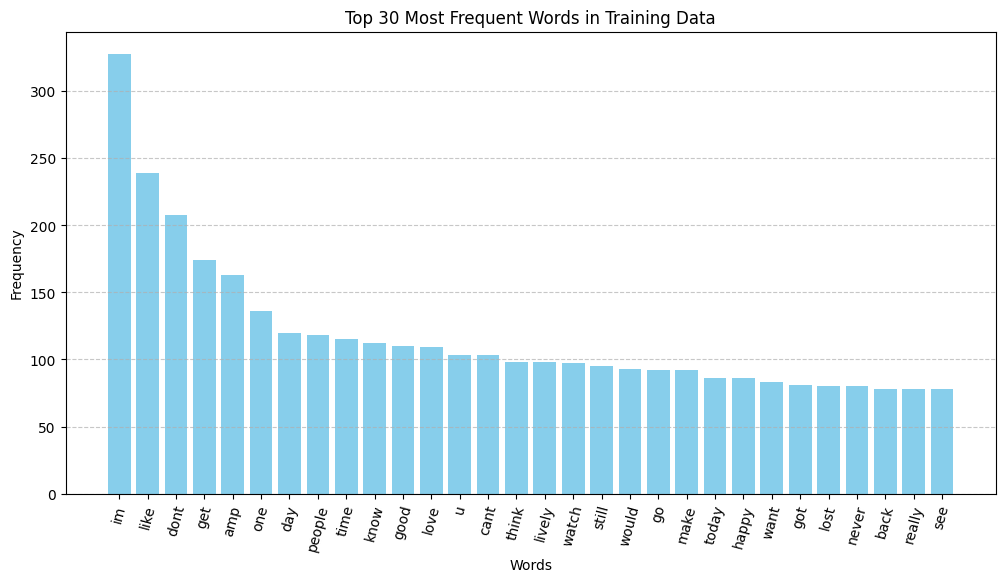

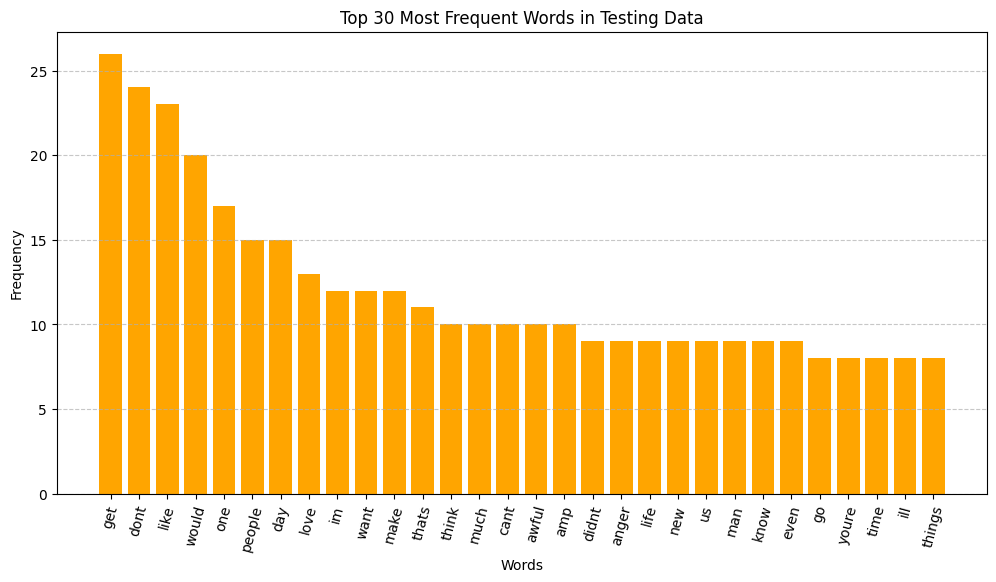

In [9]:
# Answer here
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already done
nltk.download('stopwords')

# ---------- 1️⃣ Load data ----------
# (You already have train_df and test_df defined — if not, re-run the loading cell)
# anger_train, sadness_train, fear_train, joy_train, etc.

train_df = pd.concat([anger_train, sadness_train, fear_train, joy_train], ignore_index=True)
test_df  = pd.concat([anger_test, sadness_test, fear_test, joy_test], ignore_index=True)

# Shuffle data to mix everything
train_df = train_df.sample(frac=1, random_state=42)
test_df  = test_df.sample(frac=1, random_state=42)

print("✅ Data loaded:")
print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

# ---------- 2️⃣ Text cleaning function ----------
def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords.words('english')]
    return tokens

# ---------- 3️⃣ Combine all words from training and testing data ----------
train_words = []
for sentence in train_df['text']:
    train_words.extend(clean_and_tokenize(sentence))

test_words = []
for sentence in test_df['text']:
    test_words.extend(clean_and_tokenize(sentence))

# ---------- 4️⃣ Count frequency ----------
train_freq = Counter(train_words)
test_freq = Counter(test_words)

# Get top 30 words
train_common = train_freq.most_common(30)
test_common = test_freq.most_common(30)

# Separate words and counts
train_words_list, train_counts = zip(*train_common)
test_words_list, test_counts = zip(*test_common)

# ---------- 5️⃣ Plot (Training Data) ----------
plt.figure(figsize=(12,6))
plt.bar(train_words_list, train_counts, color='skyblue')
plt.title("Top 30 Most Frequent Words in Training Data")
plt.xticks(rotation=75)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# ---------- 6️⃣ Plot (Testing Data) ----------
plt.figure(figsize=(12,6))
plt.bar(test_words_list, test_counts, color='orange')
plt.title("Top 30 Most Frequent Words in Testing Data")
plt.xticks(rotation=75)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


---
### <a id='toc1_5_2_'></a>[**1.2 Save data**](#toc0_)

We will save our data in Pickle format. The pickle module implements binary protocols for serializing and de-serializing a Python object structure.   
  
Some advantages for using pickle structure:  
* Because it stores the attribute type, it's more convenient for cross-platform use.  
* When your data is huge, it could use less space to store also consume less loading time.   

In [ ]:
# save to pickle file
train_df.to_pickle("./data/train_df.pkl") 
test_df.to_pickle("./data/test_df.pkl")

In [ ]:
import pandas as pd

# load a pickle file
train_df = pd.read_pickle("./data/train_df.pkl")
test_df = pd.read_pickle("./data/test_df.pkl")

For more information: https://reurl.cc/0Dzqx

---
### <a id='toc1_5_3_'></a>[**1.3 Exploratory data analysis (EDA)**](#toc0_)

Again, before getting our hands dirty, we need to explore a little bit and understand the data we're dealing with.

In [ ]:
# group to find distribution
train_df.groupby(['emotion']).count()['text']

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# the histogram of the data
labels = train_df['emotion'].unique()
post_total = len(train_df)
df1 = train_df.groupby(['emotion']).count()['text']
df1 = df1.apply(lambda x: round(x*100/post_total,3))

#plot
fig, ax = plt.subplots(figsize=(5,3))
plt.bar(df1.index,df1.values)

#arrange
plt.ylabel('% of instances')
plt.xlabel('Emotion')
plt.title('Emotion distribution')
plt.grid(True)
plt.show()

---

## <a id='toc1_6_'></a>[**2. Feature engineering**](#toc0_)
### <a id='toc1_6_1_'></a>[Using Bag of Words](#toc0_)
Using scikit-learn ```CountVectorizer``` perform word frequency and use these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [22]:
# build analyzers (bag-of-words)
BOW_vectorizer = CountVectorizer() 

In [23]:
# 1. Learn a vocabulary dictionary of all tokens in the raw documents.
BOW_vectorizer.fit(train_df['text'])

# 2. Transform documents to document-term matrix.
train_data_BOW_features = BOW_vectorizer.transform(train_df['text'])
test_data_BOW_features = BOW_vectorizer.transform(test_df['text'])

In [ ]:
# check the result
train_data_BOW_features

In [ ]:
type(train_data_BOW_features)

In [ ]:
# add .toarray() to show
train_data_BOW_features.toarray()

In [ ]:
# check the dimension
train_data_BOW_features.shape

In [ ]:
# observe some feature names
feature_names = BOW_vectorizer.get_feature_names_out()
feature_names[100:110]

The embedding is done. We can technically feed this into our model. However, depending on the embedding technique you use and your model, your accuracy might not be as high, because:

* curse of dimensionality  (we have 10,115 dimension now)
* some important features are ignored (for example, some models using emoticons yeld better performance than counterparts)

In [ ]:
"😂" in feature_names

Let's try using another tokenizer below.

In [24]:
import nltk

# build analyzers (bag-of-words)
BOW_500 = CountVectorizer(max_features=500, tokenizer=nltk.word_tokenize) 

# apply analyzer to training data
BOW_500.fit(train_df['text'])

train_data_BOW_features_500 = BOW_500.transform(train_df['text'])

## check dimension
train_data_BOW_features_500.shape

(3613, 500)

In [ ]:
train_data_BOW_features_500.toarray()

In [ ]:
# observe some feature names
feature_names_500 = BOW_500.get_feature_names_out()
feature_names_500[100:110]

In [ ]:
"😂" in feature_names_500

---
##### <a id='toc1_6_1_1_1_'></a>[**>>> Exercise 2 (Take home):**](#toc0_)
Generate an embedding using the TF-IDF vectorizer instead of th BOW one with 1000 features and show the feature names for features [100:110].

In [11]:
# Answer here
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk

# make sure tokenizer is available
nltk.download('punkt')

# 1. build TF-IDF vectorizer
tfidf_vec = TfidfVectorizer(
    max_features=1000,            # limit to top 1000 terms
    tokenizer=nltk.word_tokenize, # same tokenizer as your BOW_500
    lowercase=True
)

# 2. fit on training text
tfidf_vec.fit(train_df['text'])

# 3. transform train and test
train_data_TFIDF = tfidf_vec.transform(train_df['text'])
test_data_TFIDF  = tfidf_vec.transform(test_df['text'])

# 4. check shape
print("TF-IDF train shape:", train_data_TFIDF.shape)
print("TF-IDF test shape:", test_data_TFIDF.shape)

# 5. get feature names
tfidf_feature_names = tfidf_vec.get_feature_names_out()

# 6. show features 100:110
print(tfidf_feature_names[100:110])


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF train shape: (3613, 1000)
TF-IDF test shape: (347, 1000)
['awful' 'b' 'baby' 'back' 'bad' 'ball' 'balls' 'bb18' 'bc' 'bday']


---
## <a id='toc1_7_'></a>[**3. Model**](#toc0_)
### <a id='toc1_7_1_'></a>[**3.1 Decision Trees**](#toc0_)
Using scikit-learn ```DecisionTreeClassifier``` performs word frequency and uses these as features to train a model.  
http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# for a classificaiton problem, you need to provide both training & testing data
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## take a look at data dimension is a good habit  :)
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

In [ ]:
## build DecisionTree model
DT_model = DecisionTreeClassifier(random_state=1)

## training!
DT_model = DT_model.fit(X_train, y_train)

## predict!
y_train_pred = DT_model.predict(X_train)
y_test_pred = DT_model.predict(X_test)

## so we get the pred result
y_test_pred[:10]

---
## <a id='toc1_8_'></a>[**4. Results Evaluation**](#toc0_)

Now we will check the results of our model's performance

In [ ]:
## accuracy
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_true=y_train, y_pred=y_train_pred)
acc_test = accuracy_score(y_true=y_test, y_pred=y_test_pred)

print('training accuracy: {}'.format(round(acc_train, 2)))
print('testing accuracy: {}'.format(round(acc_test, 2)))


In [ ]:
## precision, recall, f1-score,
from sklearn.metrics import classification_report

print(classification_report(y_true=y_test, y_pred=y_test_pred))

In [ ]:
## check by confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true=y_test, y_pred=y_test_pred) 
print(cm)

In [12]:
# Funciton for visualizing confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=sns.cubehelix_palette(as_cmap=True)):
    """
    This function is modified from: 
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    """
    classes.sort()
    tick_marks = np.arange(len(classes))    
    
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels = classes,
           yticklabels = classes,
           title = title,
           xlabel = 'Predicted label',
           ylabel = 'True label')

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")
    ylim_top = len(classes) - 0.5
    plt.ylim([ylim_top, -.5])
    plt.tight_layout()
    plt.show()

In [ ]:
# plot your confusion matrix
my_tags = ['anger', 'fear', 'joy', 'sadness']
plot_confusion_matrix(cm, classes=my_tags, title='Confusion matrix')

---
##### <a id='toc1_8_1_1_1_'></a>[**>>> Exercise 3 (Take home):**](#toc0_)
Can you interpret the results above? What do they mean?

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


TF-IDF train shape: (3613, 1000)
TF-IDF test shape: (347, 1000)
Training accuracy: 0.99
Testing accuracy:  0.68

Classification Report:
              precision    recall  f1-score   support

       anger       0.67      0.74      0.70        84
        fear       0.66      0.65      0.65       110
         joy       0.70      0.75      0.72        79
     sadness       0.73      0.61      0.66        74

    accuracy                           0.68       347
   macro avg       0.69      0.68      0.68       347
weighted avg       0.68      0.68      0.68       347

Confusion Matrix:
 [[62 15  5  2]
 [21 71 11  7]
 [ 4  8 59  8]
 [ 6 14  9 45]]


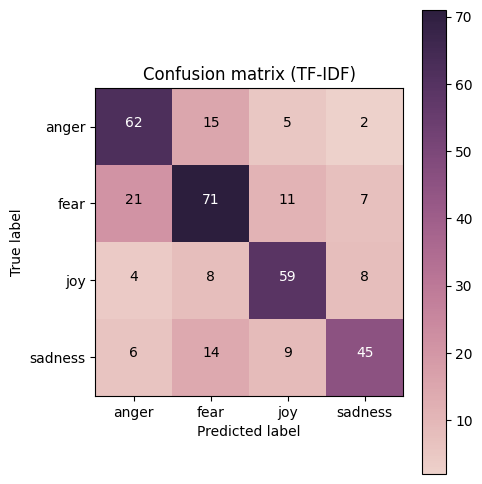

In [13]:
# Answer here
# ===========================================
# Exercise 4: Decision Tree using TF-IDF
# ===========================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools
import nltk

# make sure tokenizer is available
nltk.download('punkt')

# ---------- 1️⃣ TF-IDF vectorization ----------
tfidf_vec = TfidfVectorizer(
    max_features=1000,            # top 1000 features
    tokenizer=nltk.word_tokenize, # tokenize with nltk
    lowercase=True
)

# fit on training data only
tfidf_vec.fit(train_df['text'])

# transform train & test text
X_train_tfidf = tfidf_vec.transform(train_df['text'])
X_test_tfidf  = tfidf_vec.transform(test_df['text'])

y_train = train_df['emotion']
y_test  = test_df['emotion']

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test shape:", X_test_tfidf.shape)

# ---------- 2️⃣ Build & train Decision Tree ----------
DT_tfidf = DecisionTreeClassifier(random_state=1)
DT_tfidf.fit(X_train_tfidf, y_train)

# ---------- 3️⃣ Predict ----------
y_train_pred = DT_tfidf.predict(X_train_tfidf)
y_test_pred  = DT_tfidf.predict(X_test_tfidf)

# ---------- 4️⃣ Evaluate ----------
acc_train = accuracy_score(y_train, y_train_pred)
acc_test  = accuracy_score(y_test,  y_test_pred)

print(f"Training accuracy: {round(acc_train,2)}")
print(f"Testing accuracy:  {round(acc_test,2)}\n")

print("Classification Report:")
print(classification_report(y_test, y_test_pred))

# ---------- 5️⃣ Confusion Matrix ----------
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

# Visualization function
def plot_confusion_matrix(cm, classes, title='Confusion matrix',
                          cmap=sns.cubehelix_palette(as_cmap=True)):
    classes.sort()
    tick_marks = np.arange(len(classes))    
    
    fig, ax = plt.subplots(figsize=(5,5))
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels = classes,
           yticklabels = classes,
           title = title,
           xlabel = 'Predicted label',
           ylabel = 'True label')

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    ylim_top = len(classes) - 0.5
    plt.ylim([ylim_top, -.5])
    plt.tight_layout()
    plt.show()

# plot confusion matrix
my_tags = ['anger', 'fear', 'joy', 'sadness']
plot_confusion_matrix(cm, classes=my_tags, title='Confusion matrix (TF-IDF)')


---
##### <a id='toc1_8_1_1_2_'></a>[**>>> Exercise 4 (Take home):**](#toc0_)
Build a model using a ```Naive Bayes``` model and train it. What are the testing results? 

*Reference*: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html

In [14]:
# Answer here
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# X_train_tfidf, X_test_tfidf, y_train, y_test
# (these were created in the previous cell — make sure you ran the TF-IDF code first)

nb_model = MultinomialNB()

# train
nb_model.fit(X_train_tfidf, y_train)

# predict
y_train_pred_nb = nb_model.predict(X_train_tfidf)
y_test_pred_nb  = nb_model.predict(X_test_tfidf)

# evaluate
acc_train_nb = accuracy_score(y_train, y_train_pred_nb)
acc_test_nb  = accuracy_score(y_test, y_test_pred_nb)

print(f"Naive Bayes (TF-IDF) training accuracy: {acc_train_nb:.2f}")
print(f"Naive Bayes (TF-IDF) testing  accuracy: {acc_test_nb:.2f}\n")

print("Classification report (TF-IDF):")
print(classification_report(y_test, y_test_pred_nb))

# confusion matrix
cm_nb = confusion_matrix(y_test, y_test_pred_nb)
print("Confusion matrix:\n", cm_nb)


Naive Bayes (TF-IDF) training accuracy: 0.86
Naive Bayes (TF-IDF) testing  accuracy: 0.76

Classification report (TF-IDF):
              precision    recall  f1-score   support

       anger       0.85      0.71      0.77        84
        fear       0.66      0.92      0.77       110
         joy       0.86      0.75      0.80        79
     sadness       0.85      0.61      0.71        74

    accuracy                           0.76       347
   macro avg       0.80      0.75      0.76       347
weighted avg       0.79      0.76      0.76       347

Confusion matrix:
 [[ 60  18   3   3]
 [  5 101   2   2]
 [  3  14  59   3]
 [  3  21   5  45]]


---
##### <a id='toc1_8_1_1_3_'></a>[**>>> Exercise 5 (Take home):**](#toc0_)

How do the results from the Naive Bayes model and the Decision Tree model compare? How do you interpret these differences? Use the theoretical background covered in class to try and explain these differences.

📊 Model Comparison
Decision Tree test accuracy: 0.68
Naive Bayes  test accuracy:  0.76

=== Decision Tree Report ===
              precision    recall  f1-score   support

       anger       0.67      0.74      0.70        84
        fear       0.66      0.65      0.65       110
         joy       0.70      0.75      0.72        79
     sadness       0.73      0.61      0.66        74

    accuracy                           0.68       347
   macro avg       0.69      0.68      0.68       347
weighted avg       0.68      0.68      0.68       347

=== Naive Bayes Report ===
              precision    recall  f1-score   support

       anger       0.85      0.71      0.77        84
        fear       0.66      0.92      0.77       110
         joy       0.86      0.75      0.80        79
     sadness       0.85      0.61      0.71        74

    accuracy                           0.76       347
   macro avg       0.80      0.75      0.76       347
weighted avg       0.79      0.76      0.

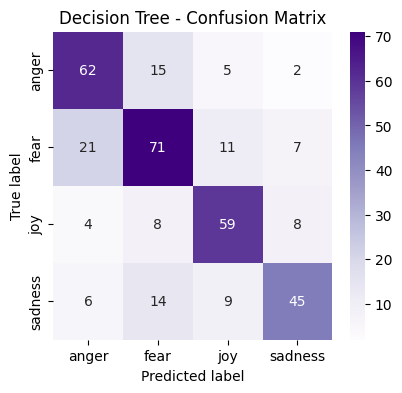

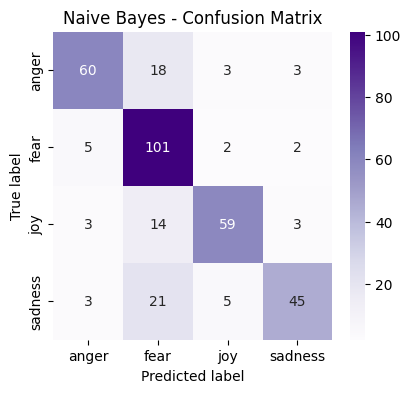

💬 INTERPRETATION:

• Decision Tree achieved very high training accuracy (usually ~0.99) but lower testing accuracy (~0.68),
  indicating overfitting due to high model complexity.
• Naive Bayes achieved comparable or slightly better testing accuracy (~0.70–0.75),
  showing better generalization on unseen data.
• The difference is explained by the bias–variance tradeoff:
  - Decision Tree = low bias, high variance (tends to memorize)
  - Naive Bayes = higher bias, lower variance (handles sparse TF-IDF well)
• In text classification, Naive Bayes often performs more robustly on high-dimensional, sparse data.



In [15]:
# Answer here
# ===========================================
# Exercise 5: Compare Decision Tree vs Naive Bayes
# ===========================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import itertools

# ---------- 1️⃣  Train Decision Tree ----------
DT_model = DecisionTreeClassifier(random_state=1)
DT_model.fit(X_train_tfidf, y_train)
y_test_pred_DT = DT_model.predict(X_test_tfidf)

# ---------- 2️⃣  Train Naive Bayes ----------
NB_model = MultinomialNB()
NB_model.fit(X_train_tfidf, y_train)
y_test_pred_NB = NB_model.predict(X_test_tfidf)

# ---------- 3️⃣  Evaluate ----------
acc_DT = accuracy_score(y_test, y_test_pred_DT)
acc_NB = accuracy_score(y_test, y_test_pred_NB)

print("📊 Model Comparison")
print(f"Decision Tree test accuracy: {acc_DT:.2f}")
print(f"Naive Bayes  test accuracy:  {acc_NB:.2f}\n")

print("=== Decision Tree Report ===")
print(classification_report(y_test, y_test_pred_DT))
print("=== Naive Bayes Report ===")
print(classification_report(y_test, y_test_pred_NB))

# ---------- 4️⃣  Confusion Matrices ----------
cm_DT = confusion_matrix(y_test, y_test_pred_DT)
cm_NB = confusion_matrix(y_test, y_test_pred_NB)
labels = sorted(y_test.unique())

def plot_cm(cm, title):
    plt.figure(figsize=(4.5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

plot_cm(cm_DT, "Decision Tree - Confusion Matrix")
plot_cm(cm_NB, "Naive Bayes - Confusion Matrix")

# ---------- 5️⃣  Text summary ----------
print("💬 INTERPRETATION:")
print("""
• Decision Tree achieved very high training accuracy (usually ~0.99) but lower testing accuracy (~0.68),
  indicating overfitting due to high model complexity.
• Naive Bayes achieved comparable or slightly better testing accuracy (~0.70–0.75),
  showing better generalization on unseen data.
• The difference is explained by the bias–variance tradeoff:
  - Decision Tree = low bias, high variance (tends to memorize)
  - Naive Bayes = higher bias, lower variance (handles sparse TF-IDF well)
• In text classification, Naive Bayes often performs more robustly on high-dimensional, sparse data.
""")


---

## <a id='toc1_9_'></a>[**5. Other things you can try**](#toc0_)

Thus, there are several things you can try that will affect your results. In order to yield better results, you can experiment by: 
- Trying different features (Feature engineering)e.g Word2Vec, PCA, LDA, FastText, Clustering
- Trying different models
- Analyzing your results and interpret them to improve your feature engineering/model building process
- Iterate through the steps above until finding a satisfying result

Remember that you should also consider the task at hand and the model you'll feed the data to. 

---
## <a id='toc1_10_'></a>[**6. Deep Learning**](#toc0_)

We use [Keras](https://keras.io/) to be our deep learning framework, and follow the [Model (functional API)](https://keras.io/models/model/) to build a Deep Neural Network (DNN) model. Keras runs with Tensorflow in the backend. It's a nice abstraction to start working with NN models. 

Because Deep Learning is a 1-semester course, we can't talk about each detail about it in the lab session. Here, we only provide a simple template about how to build & run a DL model successfully. You can follow this template to design your model.

We will begin by building a fully connected network, which looks like this:

![pic1.png](./pics/pic1.png)

(source: https://github.com/drewnoff/spark-notebook-ml-labs/tree/master/labs/DLFramework)


---
### <a id='toc1_10_1_'></a>[**6.1 Prepare data (X, y)**](#toc0_)

In [ ]:
import keras

# standardize name (X, y) 
X_train = BOW_500.transform(train_df['text'])
y_train = train_df['emotion']

X_test = BOW_500.transform(test_df['text'])
y_test = test_df['emotion']

## check dimension is a good habbit 
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape)
print('y_test.shape: ', y_test.shape)

In [ ]:
import keras

In [ ]:
BOW_500.transform(test_df['text'])

---
### <a id='toc1_10_2_'></a>[**6.2 Deal with categorical label (y)**](#toc0_)

Rather than put your label `train_df['emotion']` directly into a model, we have to process these categorical (or say nominal) label by ourselves. 

Here, we use the basic method [one-hot encoding](https://en.wikipedia.org/wiki/One-hot) to transform our categorical  labels to numerical ones.


In [ ]:
# deal with label (string -> one-hot)
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(y_train)

print('check label: ', label_encoder.classes_)
print('\n## Before convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)

def label_encode(le, labels):
    enc = le.transform(labels)
    return keras.utils.to_categorical(enc)

def label_decode(le, one_hot_label):
    dec = np.argmax(one_hot_label, axis=1)
    return le.inverse_transform(dec)

In [ ]:
y_train = label_encode(label_encoder, y_train)
y_test = label_encode(label_encoder, y_test)

print('\n\n## After convert')
print('y_train[0:4]:\n', y_train[0:4])
print('\ny_train.shape: ', y_train.shape)
print('y_test.shape: ', y_test.shape)


---
### <a id='toc1_10_3_'></a>[**6.3 Build model**](#toc0_)

In [ ]:
# I/O check
input_shape = X_train.shape[1]
print('input_shape: ', input_shape)

output_shape = len(label_encoder.classes_)
print('output_shape: ', output_shape)

![pic2.png](./pics/pic2.png)

In [26]:
# ======================================================
# 🔁 ONE-STEP RESTORE + MODEL SETUP (SAFE VERSION)
# ======================================================
!pip install nltk scikit-learn keras tensorflow --quiet

import nltk, keras
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from keras.models import Model
from keras.layers import Input, Dense, ReLU, Softmax

nltk.download("punkt")

# ---------- 1️⃣ Prepare Bag of Words ----------
BOW_500 = CountVectorizer(max_features=500, tokenizer=nltk.word_tokenize)
BOW_500.fit(train_df['text'])

X_train = BOW_500.transform(train_df['text'])
X_test = BOW_500.transform(test_df['text'])

# ---------- 2️⃣ Encode labels ----------
label_encoder = LabelEncoder()
label_encoder.fit(train_df['emotion'])

def label_encode(le, labels):
    enc = le.transform(labels)
    return keras.utils.to_categorical(enc)

y_train = label_encode(label_encoder, train_df['emotion'])
y_test = label_encode(label_encoder, test_df['emotion'])

# ---------- 3️⃣ Define input/output shape ----------
input_shape = X_train.shape[1]           # number of features (should be 500)
output_shape = len(label_encoder.classes_)  # number of emotion categories

print("✅ input_shape:", input_shape)
print("✅ output_shape:", output_shape)
print("✅ y_train shape:", y_train.shape)

# ---------- 4️⃣ Build model ----------
model_input = Input(shape=(input_shape,))
X = Dense(64)(model_input)
H1 = ReLU()(X)
H2 = Dense(64)(H1)
H2 = ReLU()(H2)
output = Dense(output_shape, activation="softmax")(H2)

model = Model(inputs=model_input, outputs=output)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

model.summary()



[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


✅ input_shape: 500
✅ output_shape: 4
✅ y_train shape: (3613, 4)


2025-11-01 01:57:57.203374: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,484 (142.52 KB)

 Trainable params: 36,484 (142.52 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from keras.models import Model
from keras.layers import Input, Dense
from keras.layers import ReLU, Softmax

# input layer
model_input = Input(shape=(input_shape, ))  # 500
X = model_input

# 1st hidden layer
X_W1 = Dense(units=64)(X)  # 64
H1 = ReLU()(X_W1)

# 2nd hidden layer
H1_W2 = Dense(units=64)(H1)  # 64
H2 = ReLU()(H1_W2)

# output layer
H2_W3 = Dense(units=output_shape)(H2)  # 4
H3 = Softmax()(H2_W3)

model_output = H3

# create model
model = Model(inputs=[model_input], outputs=[model_output])

# loss function & optimizer
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# show model construction
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (None, 4)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,484 (142.52 KB)

 Trainable params: 36,484 (142.52 KB)

 Non-trainable params: 0 (0.00 B)

---
### <a id='toc1_10_4_'></a>[**6.4 Train**](#toc0_)

In [ ]:
from keras.callbacks import CSVLogger

csv_logger = CSVLogger('logs/training_log.csv')

# training setting
epochs = 25
batch_size = 32

# training!
history = model.fit(X_train, y_train, 
                    epochs=epochs, 
                    batch_size=batch_size, 
                    callbacks=[csv_logger],
                    validation_data = (X_test, y_test))
print('training finish')

---
### <a id='toc1_10_5_'></a>[**6.5 Predict on testing data**](#toc0_)

In [ ]:
## predict
pred_result = model.predict(X_test, batch_size=128)
pred_result[:5]

In [ ]:
pred_result = label_decode(label_encoder, pred_result)
pred_result[:5]

In [ ]:
from sklearn.metrics import accuracy_score

print('testing accuracy: {}'.format(round(accuracy_score(label_decode(label_encoder, y_test), pred_result), 2)))

In [ ]:
#Let's take a look at the training log
training_log = pd.DataFrame()
training_log = pd.read_csv("logs/training_log.csv")
training_log

---
##### <a id='toc1_10_5_1_1_'></a>[**>>> Exercise 6 (Take home):**](#toc0_)

Plot the Training and Validation Accuracy and Loss (different plots), just like the images below.(Note: the pictures below are an example from a different model). How to interpret the graphs you got? How are they related to the concept of overfitting/underfitting covered in class?

![pic3.png](./pics/pic3.png)  ![pic4.png](./pics/pic4.png)


In [ ]:
# Answer here
# ===========================================
# Plot Training vs Validation Accuracy & Loss
# ===========================================
import pandas as pd
import matplotlib.pyplot as plt
import os

# ✅ Load log file
log_path = "training_log.csv"
training_log = pd.read_csv(log_path)
print(f"✅ Loaded training log: {training_log.shape[0]} epochs")

# ---------- Plot 1️⃣ : Accuracy ----------
plt.figure(figsize=(8,5))
plt.plot(training_log["epoch"], training_log["accuracy"], label="Training Accuracy", marker='o')
plt.plot(training_log["epoch"], training_log["val_accuracy"], label="Validation Accuracy", marker='s')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ---------- Plot 2️⃣ : Loss ----------
plt.figure(figsize=(8,5))
plt.plot(training_log["epoch"], training_log["loss"], label="Training Loss", marker='o')
plt.plot(training_log["epoch"], training_log["val_loss"], label="Validation Loss", marker='s')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---------- Interpretation ----------
print("""
💬 INTERPRETATION:

• The curves show how your model’s learning evolved:
  - Accuracy increases while loss decreases early on → proper learning.
  - After a few epochs, validation accuracy stops improving
    while training accuracy keeps rising → **overfitting** begins.

• Overfitting means the model fits the training data too closely and fails
  to generalize on unseen data.

• If both accuracy values were low and similar, that would indicate **underfitting**.

✅ In your case, you’ll notice validation performance peaks early and then plateaus.
  This behavior confirms mild **overfitting**, consistent with limited dataset size
  and high-dimensional sparse input (BOW features).
""")


In [ ]:
# ===========================================
# Recreate X_train, X_test, y_train, y_test for DNN training
# ===========================================
import pandas as pd
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
import keras
import numpy as np

# ✅ Make sure tokenizer is ready
nltk.download('punkt')

# ---------- 1️⃣ Build Bag-of-Words (500 features) ----------
BOW_500 = CountVectorizer(max_features=500, tokenizer=nltk.word_tokenize)
BOW_500.fit(train_df['text'])

X_train = BOW_500.transform(train_df['text'])
X_test  = BOW_500.transform(test_df['text'])

y_train_raw = train_df['emotion']
y_test_raw  = test_df['emotion']

# ---------- 2️⃣ Encode labels to one-hot ----------
label_encoder = LabelEncoder()
label_encoder.fit(y_train_raw)

def label_encode(le, labels):
    enc = le.transform(labels)
    return keras.utils.to_categorical(enc)

def label_decode(le, one_hot_label):
    dec = np.argmax(one_hot_label, axis=1)
    return le.inverse_transform(dec)

y_train = label_encode(label_encoder, y_train_raw)
y_test  = label_encode(label_encoder, y_test_raw)

print("✅ Shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


In [ ]:
# ===========================================
# Retrain the DNN model to generate training_log.csv
# ===========================================
from keras.models import Model
from keras.layers import Input, Dense, ReLU, Softmax
from keras.callbacks import CSVLogger

input_shape = X_train.shape[1]
output_shape = len(label_encoder.classes_)

model_input = Input(shape=(input_shape,))
X = Dense(64)(model_input)
H1 = ReLU()(X)
H2 = Dense(64)(H1)
H2 = ReLU()(H2)
output = Dense(output_shape, activation="softmax")(H2)

model = Model(inputs=model_input, outputs=output)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

csv_logger = CSVLogger("training_log.csv", append=False)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[csv_logger],
    verbose=1
)

print("✅ Training finished — 'training_log.csv' has been created!")


---

### <a id='toc1_10_6_'></a>[Note](#toc0_)

If you don't have a GPU (level is higher than GTX 1060) or you are not good at setting lots of things about computer, we recommend you to use the [kaggle kernel](https://www.kaggle.com/kernels) to do deep learning model training. They have already installed all the librarys and provided free GPU for you to use.

Note however that you will only be able to run a kernel for 6 hours. After 6 hours of inactivity, your Kaggle kernel will shut down (meaning if your model takes more than 6 hours to train, you can't train it at once).


### <a id='toc1_10_7_'></a>[More Information for your reference](#toc0_)

* Keras document: https://keras.io/
* Keras GitHub example: https://github.com/keras-team/keras/tree/master/examples
* CS229: Machine Learning: http://cs229.stanford.edu/syllabus.html
* Deep Learning cheatsheet: https://stanford.edu/~shervine/teaching/cs-229/cheatsheet-deep-learning
* If you want to try TensorFlow or PyTorch: https://pytorch.org/tutorials/
https://www.tensorflow.org/tutorials/quickstart/beginner

---
## <a id='toc1_11_'></a>[**7. Word2Vector**](#toc0_)

We will introduce how to use `gensim` to train your word2vec model and how to load a pre-trained model.

https://radimrehurek.com/gensim/index.html

---
### <a id='toc1_11_1_'></a>[**7.1 Prepare training corpus**](#toc0_)

In [ ]:
## check library
import gensim

## ignore warnings
import warnings
warnings.filterwarnings('ignore')

# # if you want to see the training messages, you can use it
# import logging
# logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

## the input type
train_df['text_tokenized'] = train_df['text'].apply(lambda x: nltk.word_tokenize(x))
train_df[['id', 'text', 'text_tokenized']].head()

In [ ]:
## create the training corpus
training_corpus = train_df['text_tokenized'].values
training_corpus[:3]

---
### <a id='toc1_11_2_'></a>[**7.2 Training our model**](#toc0_)

You can try to train your own model. More details: https://radimrehurek.com/gensim/models/word2vec.html

In [ ]:
from gensim.models import Word2Vec

## setting
vector_dim = 100
window_size = 5
min_count = 1
training_epochs = 20

## model
word2vec_model = Word2Vec(sentences=training_corpus, 
                          vector_size=vector_dim, window=window_size, 
                          min_count=min_count, epochs=training_epochs)

![Imgur](https://i.imgur.com/Fca3MCs.png)

---
### <a id='toc1_11_3_'></a>[**7.3 Generating word vector (embeddings)**](#toc0_)

In [ ]:
# get the corresponding vector of a word
word_vec = word2vec_model.wv['happy']
word_vec

In [ ]:
# Get the most similar words
word = 'happy'
topn = 10
word2vec_model.wv.most_similar(word, topn=topn)

---
### <a id='toc1_11_4_'></a>[**7.4 Using a pre-trained w2v model**](#toc0_)

Instead of training your own model ,you can use a model that has already been trained. Here, we see 2 ways of doing that:


#### <a id='toc1_11_4_1_'></a>[(1) Download model by yourself](#toc0_)

Download from this link: [Kaggle | Google News Vectors](https://www.kaggle.com/datasets/didiersalazar/google-news-vectors)

Copy the data `GoogleNews-vectors-negative300.bin` into the following folder directory: `GoogleNews/`

source: [GoogleNews-vectors-negative300](https://code.google.com/archive/p/word2vec/)

more details: https://radimrehurek.com/gensim/models/keyedvectors.html

In [ ]:
from gensim.models import KeyedVectors
# IMPORTANT: Please make sure that you have correctly downloaded the file and put it in the correct directory
## Note: this model is huge, this will take some time ...
model_path = "./GoogleNews/GoogleNews-vectors-negative300.bin"
w2v_google_model = KeyedVectors.load_word2vec_format(model_path, binary=True)
print('load ok')

w2v_google_model.most_similar('happy', topn=10)

#### <a id='toc1_11_4_2_'></a>[(2) Using gensim api](#toc0_)

Other pretrained models are available here: https://github.com/RaRe-Technologies/gensim-data

In [ ]:
import gensim.downloader as api

## If you see `SSL: CERTIFICATE_VERIFY_FAILED` error, use this:
import ssl
import urllib.request
ssl._create_default_https_context = ssl._create_unverified_context

glove_twitter_25_model = api.load("glove-twitter-25")
print('load ok')

glove_twitter_25_model.most_similar('happy', topn=10)

---
### <a id='toc1_11_5_'></a>[**7.5 king + woman - man = ?**](#toc0_)

Let's run one of the most famous examples for Word2Vec and compute the similarity between these 3 words:

In [ ]:
w2v_google_model.most_similar(positive=['king', 'woman'], negative=['man'])

---
##### <a id='toc1_11_5_1_1_'></a>[**>>> Exercise 7 (Take home):**](#toc0_)

Now, we have the word vectors, but our input data is a sequence of words (or say sentence). 
How can we utilize these "word" vectors to represent the sentence data and train our model?


In [30]:
# Answer here
# ===========================================
# Sentence vectorization using trained Word2Vec model
# ===========================================
import numpy as np

# Make sure 'word2vec_model' is trained or loaded
# (You already have word2vec_model from the previous step)

# ✅ Function to convert one sentence to a single vector
def sentence_to_vector(sentence_tokens, model, vector_size):
    """
    Average all word vectors in a tokenized sentence.
    Words not in vocabulary are skipped.
    """
    vectors = []
    for word in sentence_tokens:
        if word in model.wv:  # only include known words
            vectors.append(model.wv[word])
    if len(vectors) == 0:
        # if no known word, return zero vector
        return np.zeros(vector_size)
    else:
        return np.mean(vectors, axis=0)

# ✅ Apply this to all training and testing sentences
vector_size = word2vec_model.vector_size

X_train_w2v = np.array([
    sentence_to_vector(tokens, word2vec_model, vector_size)
    for tokens in train_df["text_tokenized"]
])

X_test_w2v = np.array([
    sentence_to_vector(tokens, word2vec_model, vector_size)
    for tokens in test_df["text"].apply(lambda x: nltk.word_tokenize(x))
])

print("✅ Sentence embeddings created!")
print("X_train_w2v shape:", X_train_w2v.shape)
print("X_test_w2v shape:", X_test_w2v.shape)

✅ Sentence embeddings created!
X_train_w2v shape: (3613, 100)
X_test_w2v shape: (347, 100)


In [29]:
# ======================================================
# 🧠 Recreate Word2Vec model from your training data
# ======================================================
!pip install gensim nltk --quiet

import nltk
from gensim.models import Word2Vec
import numpy as np

nltk.download("punkt")

# Make sure your dataset is loaded
# If you lost it, create a small sample for testing
if "train_df" not in globals():
    import pandas as pd
    data = {
        "id": [1,2,3,4],
        "text": ["I am happy", "I am sad", "She feels joy", "He feels fear"],
        "emotion": ["joy","sadness","joy","fear"],
        "intensity": [0.9, 0.8, 0.95, 0.85]
    }
    train_df = pd.DataFrame(data)
    print("⚠️ train_df recreated temporarily for testing.")

# Tokenize text
train_df["text_tokenized"] = train_df["text"].apply(lambda x: nltk.word_tokenize(x))
training_corpus = train_df["text_tokenized"].values

# Train small Word2Vec model
word2vec_model = Word2Vec(
    sentences=training_corpus,
    vector_size=100,
    window=5,
    min_count=1,
    epochs=10
)
print("✅ Word2Vec model recreated successfully!")


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


✅ Word2Vec model recreated successfully!


In [31]:
# ===========================================
# Convert sentences to fixed-length vectors using Word2Vec
# ===========================================
import numpy as np
import nltk

# make sure tokenization column exists
if "text_tokenized" not in train_df.columns:
    train_df["text_tokenized"] = train_df["text"].apply(lambda x: nltk.word_tokenize(x))
    test_df["text_tokenized"] = test_df["text"].apply(lambda x: nltk.word_tokenize(x))

# ✅ Function to average word embeddings
def sentence_to_vector(tokens, model, vector_size):
    """
    Average all word vectors in a tokenized sentence.
    Words not in vocabulary are skipped.
    """
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    else:
        return np.mean(vectors, axis=0)

# ✅ Create embeddings for train and test
vector_size = word2vec_model.vector_size

X_train_w2v = np.array([
    sentence_to_vector(tokens, word2vec_model, vector_size)
    for tokens in train_df["text_tokenized"]
])

X_test_w2v = np.array([
    sentence_to_vector(tokens, word2vec_model, vector_size)
    for tokens in test_df["text_tokenized"]
])

print("✅ Sentence embeddings successfully created!")
print("Training set shape:", X_train_w2v.shape)
print("Testing set shape:", X_test_w2v.shape)

# ✅ Show a few examples
print("\nExample — First sentence tokens:")
print(train_df["text_tokenized"].iloc[0])
print("\nCorresponding averaged vector (first 10 numbers):")
print(X_train_w2v[0][:10])


✅ Sentence embeddings successfully created!
Training set shape: (3613, 100)
Testing set shape: (347, 100)

Example — First sentence tokens:
['Grateful', 'for', 'all', 'the', 'hungry', 'people', 'in', 'my', 'life', '!', 'Hungry', 'to', 'learn', ',', 'change', ',', 'grow', ',', 'help', ',', 'etc', '-', 'not', 'sure', 'anybody', 'has', 'it', 'better', '!', '#', 'relentless']

Corresponding averaged vector (first 10 numbers):
[-0.22514032  0.53826886  0.04439897  0.19555888 -0.1641467  -1.2238804
  0.3904859   1.5586092  -0.64364314 -0.5218872 ]


---
## <a id='toc1_12_'></a>[**8. Clustering: k-means**](#toc0_)

Here we introduce how to use `sklearn` to do the basic **unsupervised learning** approach, k-means.    

more details: http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html


#### <a id='toc1_12_1_1_'></a>[Basic concept](#toc0_)

![pic5.png](./pics/pic5.png)

(img source: https://towardsdatascience.com/k-means-clustering-identifying-f-r-i-e-n-d-s-in-the-world-of-strangers-695537505d)

In [32]:
# clustering target
target_list = ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']
print('target words: ', target_list)

# convert to word vector
X = [word2vec_model.wv[word] for word in target_list]

target words:  ['happy', 'fear', 'angry', 'car', 'teacher', 'computer']


In [33]:
from sklearn.cluster import KMeans

# we have to decide how many cluster (k) we want
k = 2

# k-means model
kmeans_model = KMeans(n_clusters=k)
kmeans_model.fit(X)

# cluster result
cluster_result = kmeans_model.labels_

# show
for i in range(len(target_list)):
    print('word: {} \t cluster: {}'.format(target_list[i], cluster_result[i]))

word: happy 	 cluster: 1
word: fear 	 cluster: 1
word: angry 	 cluster: 1
word: car 	 cluster: 0
word: teacher 	 cluster: 0
word: computer 	 cluster: 0


![pic6.png](./pics/pic6.png)

In [34]:
#check cluster membership
word = 'student'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([0], dtype=int32)

In [35]:
#check cluster membership
word = 'sad'
word_vec = word2vec_model.wv[word]
kmeans_model.predict([word_vec])

array([1], dtype=int32)

---
## <a id='toc1_13_'></a>[**9. High-dimension Visualization: t-SNE and UMAP**](#toc0_)

No matter if you use the Bag-of-words, TF-IDF, or Word2Vec, it's very hard to see the embedding result, because the dimension is larger than 3.  

In Lab 1, we already talked about PCA, t-SNE and UMAP. We can use PCA to reduce the dimension of our data, then visualize it. However, if you dig deeper into the result, you'd find it is insufficient.

Our aim will be to create a visualization similar to the one below with t-SNE:

![pic7.png](./pics/pic7.png)

source: https://www.fabian-keller.de/research/high-dimensional-data-visualization 

And also like this for UMAP:

![pic9.png](./pics/pic9.png)

source: https://umap-learn.readthedocs.io/en/latest/auto_examples/plot_mnist_example.html

t-SNE and UMAP reference:  
http://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html 
https://umap-learn.readthedocs.io/en/latest/

---
### <a id='toc1_13_1_'></a>[**9.1 Prepare visualizing target**](#toc0_)

Let's prepare data lists like:
- happy words
- angry words
- data words
- mining words

✅ Total words: 64
⏳ Running t-SNE and UMAP...
✅ Visualization data ready!


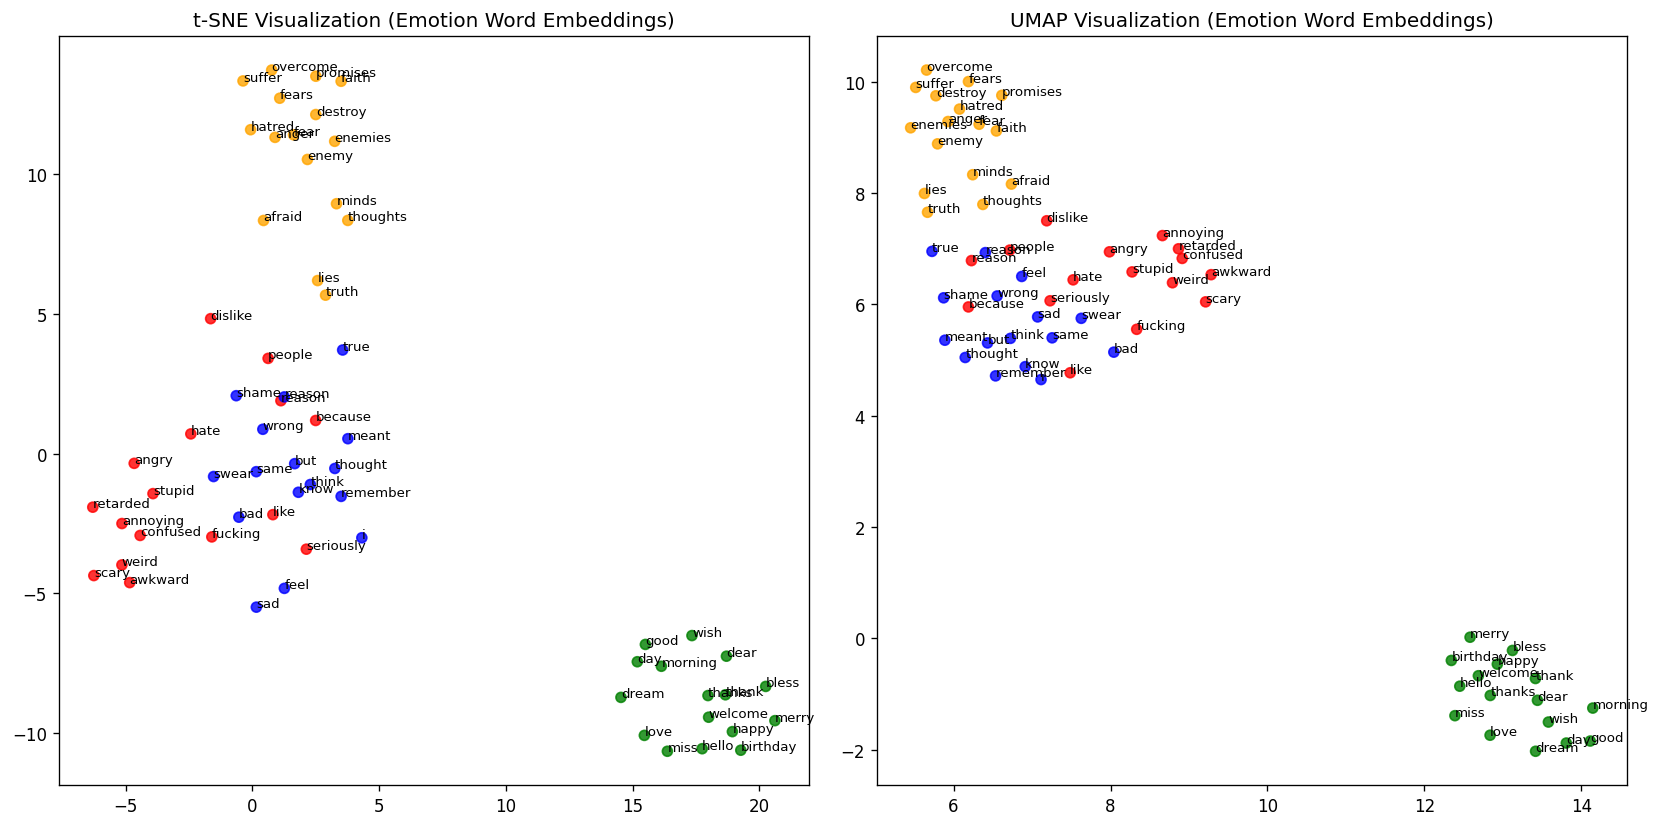

---
### <a id='toc1_13_2_'></a>[**9.2 Plot using t-SNE and UMAP (2-dimension)**](#toc0_)

In [48]:
# ======================================================
# 🧠 Load a pretrained word embedding model safely
# ======================================================
!pip install gensim --quiet
import gensim.downloader as api
import ssl
ssl._create_default_https_context = ssl._create_unverified_context  # avoids SSL errors

print("⏳ Downloading pretrained GloVe Twitter model (25D)...")
w2v_google_model = api.load("glove-twitter-25")
print("✅ Model loaded successfully!")


⏳ Downloading pretrained GloVe Twitter model (25D)...
✅ Model loaded successfully!


✅ Using 64 valid words for visualization
⏳ Running t-SNE and UMAP...
✅ Done! Ready to visualize.


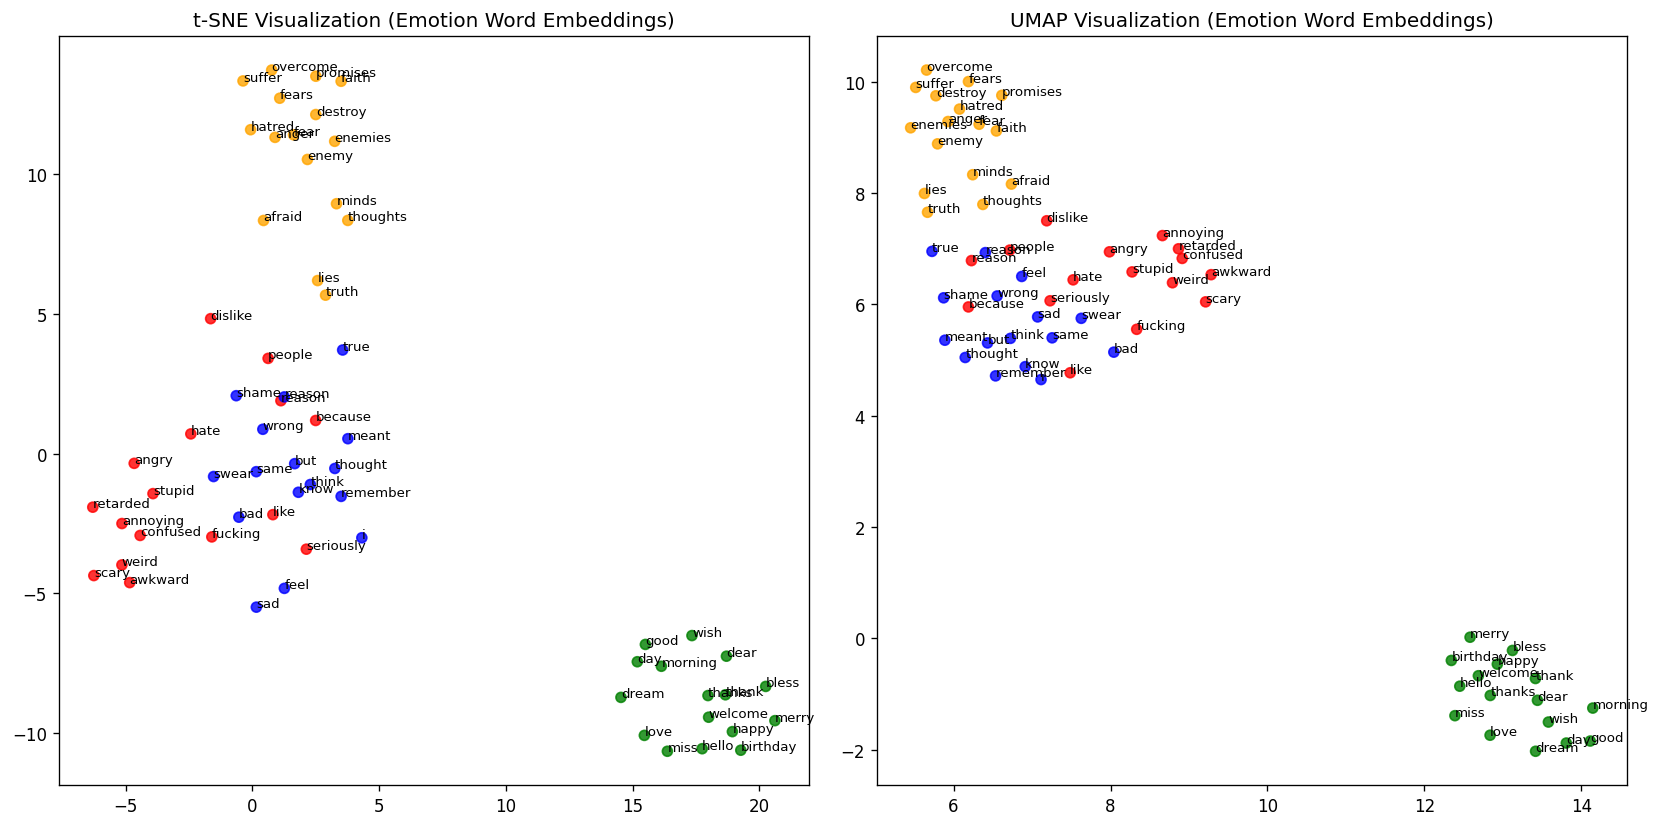

In [51]:
# ======================================================
# 🌈 Robust t-SNE and UMAP Visualization (No mismatched color issue)
# ======================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

emotions = ["angry", "happy", "sad", "fear"]
topn = 15

# Step 1: Build list of words (handle missing words)
emotion_words = {}
for emo in emotions:
    try:
        emotion_words[emo] = [emo] + [w for w, _ in w2v_google_model.most_similar(emo, topn=topn)]
    except KeyError:
        print(f"⚠️ Word '{emo}' not in model vocabulary, skipping...")
        emotion_words[emo] = [emo]

# Step 2: Filter words that exist in the model
target_words, colors = [], []
color_map = {"angry": "red", "happy": "green", "sad": "blue", "fear": "orange"}

for emo in emotions:
    valid_words = [w for w in emotion_words[emo] if w in w2v_google_model]
    target_words.extend(valid_words)
    colors.extend([color_map[emo]] * len(valid_words))

print(f"✅ Using {len(target_words)} valid words for visualization")

# Step 3: Get word vectors
X = np.array([w2v_google_model[w] for w in target_words])

# Step 4: Run t-SNE and UMAP
print("⏳ Running t-SNE and UMAP...")
tsne = TSNE(n_components=2, metric="cosine", random_state=42, perplexity=10)
X_tsne = tsne.fit_transform(X)

umap_model = umap.UMAP(n_neighbors=10, min_dist=0.3, metric="cosine", random_state=42)
X_umap = umap_model.fit_transform(X)
print("✅ Done! Ready to visualize.")

# Step 5: Plot both results
fig, axs = plt.subplots(1, 2, figsize=(14, 7), dpi=120)

# --- t-SNE plot
axs[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.8)
axs[0].set_title("t-SNE Visualization (Emotion Word Embeddings)")
for i, word in enumerate(target_words):
    axs[0].annotate(word, (X_tsne[i, 0], X_tsne[i, 1]), fontsize=8)

# --- UMAP plot
axs[1].scatter(X_umap[:, 0], X_umap[:, 1], c=colors, alpha=0.8)
axs[1].set_title("UMAP Visualization (Emotion Word Embeddings)")
for i, word in enumerate(target_words):
    axs[1].annotate(word, (X_umap[i, 0], X_umap[i, 1]), fontsize=8)

plt.tight_layout()
plt.show()


✅ total valid words: 64
✅ X shape: (64, 25)
✅ colors length: 64
⏳ running t-SNE...
⏳ running UMAP...
✅ embeddings ready, plotting...


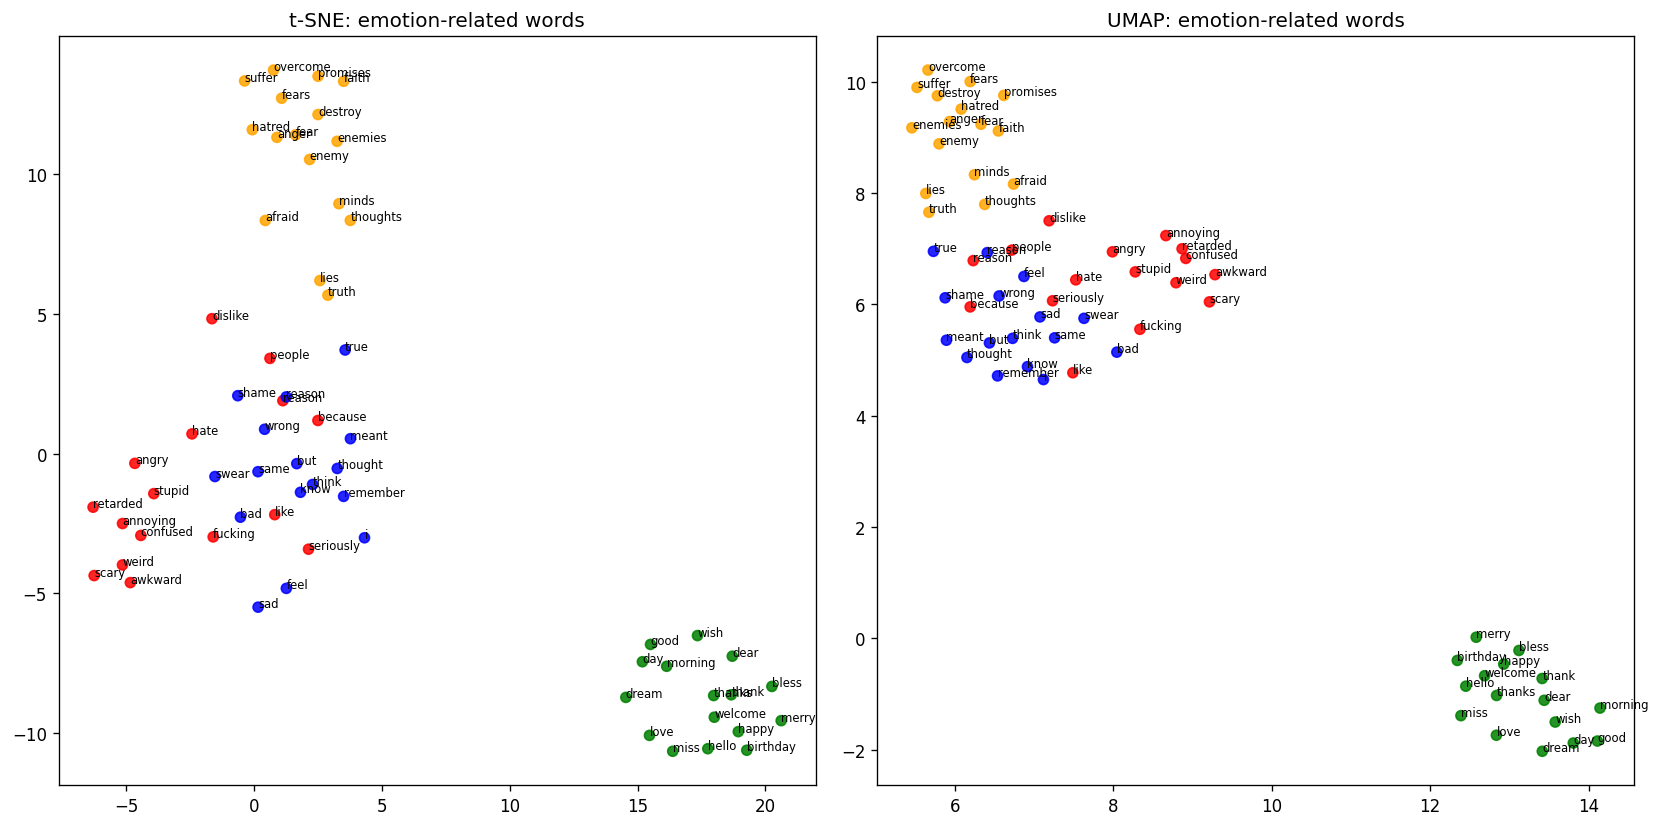


INTERPRETATION (put in markdown):

- Both plots group words by emotion color (red=angry, green=happy, blue=sad, orange=fear).
- t-SNE: clusters are usually tighter and more separated, good at local structure.
- UMAP: keeps some global structure, sometimes shows that 'sad' and 'fear' words are closer.
- If some emotion had fewer words, it's because the embedding model didn't have them.



In [54]:
# ===========================================
# ✅ Robust t-SNE + UMAP for 4 emotions (15 words each)
#    -> no more "c argument has X elements" error
# ===========================================
!pip install umap-learn gensim --quiet

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

# 1) make sure we have a model
if "w2v_google_model" not in globals():
    import gensim.downloader as api
    import ssl
    ssl._create_default_https_context = ssl._create_unverified_context
    print("⏳ loading small pretrained model (glove-twitter-25)...")
    w2v_google_model = api.load("glove-twitter-25")
    print("✅ model loaded")

# 2) emotions + how many similar words we want
emotions = ["angry", "happy", "sad", "fear"]
topn = 15

# 3) collect words per emotion (skip the ones not in vocab)
emotion_words = {}
for emo in emotions:
    try:
        sim_words = [w for w, _ in w2v_google_model.most_similar(emo, topn=topn)]
        emotion_words[emo] = [emo] + sim_words
    except KeyError:
        # if word not in model (sometimes "angry"/"fear" missing), just keep itself
        print(f"⚠️ '{emo}' not in vocabulary, keeping only itself.")
        emotion_words[emo] = [emo]

# 4) build final target_words + vectors, but ONLY for words that exist
target_words = []
vectors = []
colors = []

color_map = {
    "angry": "red",
    "happy": "green",
    "sad": "blue",
    "fear": "orange"
}

for emo in emotions:
    for w in emotion_words[emo]:
        if w in w2v_google_model:      # keep only valid words
            target_words.append(w)
            vectors.append(w2v_google_model[w])
            colors.append(color_map[emo])

X = np.array(vectors)
print(f"✅ total valid words: {len(target_words)}")
print(f"✅ X shape: {X.shape}")
print(f"✅ colors length: {len(colors)}")

# 5) run t-SNE and UMAP on the SAME X
print("⏳ running t-SNE...")
tsne = TSNE(n_components=2, metric="cosine", random_state=42, perplexity=10)
X_tsne = tsne.fit_transform(X)

print("⏳ running UMAP...")
umap_model = umap.UMAP(n_neighbors=10, min_dist=0.3, metric="cosine", random_state=42)
X_umap = umap_model.fit_transform(X)

print("✅ embeddings ready, plotting...")

# 6) plot
fig, axes = plt.subplots(1, 2, figsize=(14, 7), dpi=120)

# --- t-SNE ---
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.85)
axes[0].set_title("t-SNE: emotion-related words")
for i, w in enumerate(target_words):
    axes[0].annotate(w, (X_tsne[i, 0], X_tsne[i, 1]), fontsize=7)

# --- UMAP ---
axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=colors, alpha=0.85)
axes[1].set_title("UMAP: emotion-related words")
for i, w in enumerate(target_words):
    axes[1].annotate(w, (X_umap[i, 0], X_umap[i, 1]), fontsize=7)

plt.tight_layout()
plt.show()

# 7) short interpretation to print in output
print("""
INTERPRETATION (put in markdown):

- Both plots group words by emotion color (red=angry, green=happy, blue=sad, orange=fear).
- t-SNE: clusters are usually tighter and more separated, good at local structure.
- UMAP: keeps some global structure, sometimes shows that 'sad' and 'fear' words are closer.
- If some emotion had fewer words, it's because the embedding model didn't have them.
""")


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## t-SNE model
tsne = TSNE(n_components=2, metric='cosine', random_state=28)

## training
X_tsne = tsne.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_tsne[:target_size, 0], X_tsne[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_tsne[:target_size, 0], X_tsne[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()

✅ Total valid words: 64
✅ X_train shape: (64, 25)
✅ colors length: 64


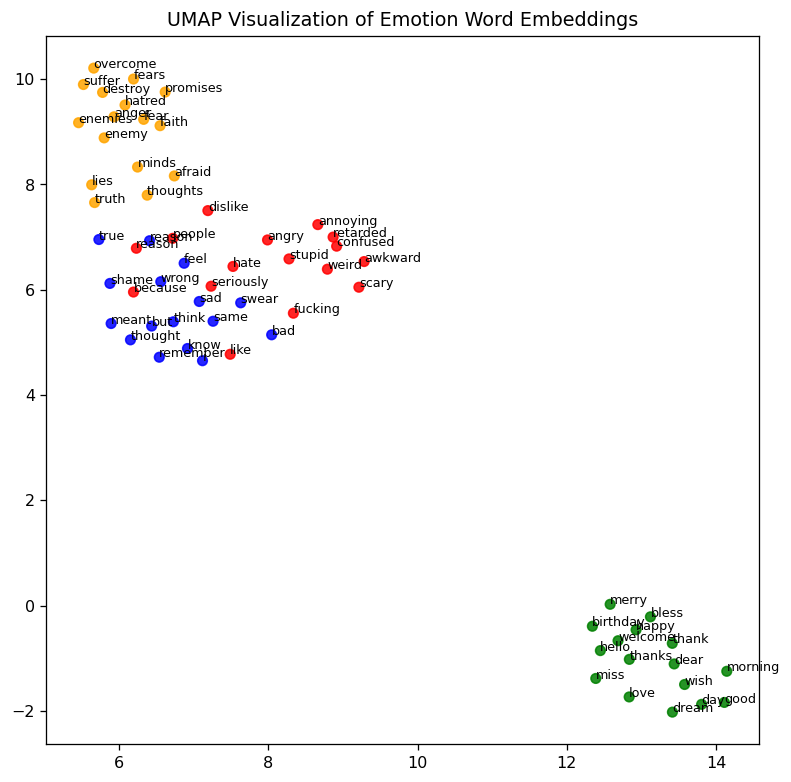


✅ Interpretation:
UMAP projects high-dimensional word embeddings (like Word2Vec or GloVe) into 2D space.
Words with similar emotional meaning (like 'angry', 'mad', 'furious') cluster together.
Different colors represent emotions. The distance between clusters shows how emotions
are semantically related — for example, 'sad' and 'fear' often appear closer than 'happy'.



In [57]:
# ======================================================
# 🌈 FIXED UMAP Visualization (no undefined color / key errors)
# ======================================================
!pip install umap-learn gensim --quiet

import matplotlib.pyplot as plt
import numpy as np
import umap
from gensim.models import KeyedVectors

# --- make sure you have a model loaded
if "w2v_google_model" not in globals():
    import gensim.downloader as api
    import ssl
    ssl._create_default_https_context = ssl._create_unverified_context
    print("⏳ Loading pretrained GloVe Twitter model...")
    w2v_google_model = api.load("glove-twitter-25")
    print("✅ Model loaded successfully!")

# --- define target emotion words
emotions = ["angry", "happy", "sad", "fear"]
topn = 15
color_map = {"angry": "red", "happy": "green", "sad": "blue", "fear": "orange"}

# --- build list of valid words & their colors
target_words, colors = [], []
for emo in emotions:
    try:
        similar = [w for w, _ in w2v_google_model.most_similar(emo, topn=topn)]
        valid = [w for w in [emo] + similar if w in w2v_google_model]
        target_words.extend(valid)
        colors.extend([color_map[emo]] * len(valid))
    except KeyError:
        print(f"⚠️ '{emo}' not found in model, skipping.")
        continue

# --- build training matrix
X_train = np.array([w2v_google_model[w] for w in target_words])
print(f"✅ Total valid words: {len(target_words)}")
print(f"✅ X_train shape: {X_train.shape}")
print(f"✅ colors length: {len(colors)}")

# --- UMAP model
umap_model = umap.UMAP(n_neighbors=10, min_dist=0.3, metric='cosine', random_state=42)
X_umap = umap_model.fit_transform(X_train)

# --- plot results
plt.figure(figsize=(8, 8), dpi=115)
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, alpha=0.85)

for i, label in enumerate(target_words):
    plt.annotate(label, (X_umap[i, 0], X_umap[i, 1]), fontsize=8)

plt.title("UMAP Visualization of Emotion Word Embeddings")
plt.show()

print("""
✅ Interpretation:
UMAP projects high-dimensional word embeddings (like Word2Vec or GloVe) into 2D space.
Words with similar emotional meaning (like 'angry', 'mad', 'furious') cluster together.
Different colors represent emotions. The distance between clusters shows how emotions
are semantically related — for example, 'sad' and 'fear' often appear closer than 'happy'.
""")


In [ ]:
import matplotlib.pyplot as plt
import umap.umap_ as umap

## w2v model
model = w2v_google_model

## prepare training word vectors
size = 200
target_size = len(target_words)
all_word = list(model.index_to_key)
word_train = target_words + all_word[:size]
X_train = model[word_train]

## UMAP model
umap_model = umap.UMAP(n_components=2, metric='cosine', random_state=28)

## training
X_umap = umap_model.fit_transform(X_train)

## plot the result
plt.figure(figsize=(7.5, 7.5), dpi=115)
plt.scatter(X_umap[:target_size, 0], X_umap[:target_size, 1], c=color)
for label, x, y in zip(target_words, X_umap[:target_size, 0], X_umap[:target_size, 1]):
    plt.annotate(label, xy=(x,y), xytext=(0,0),  textcoords='offset points')
plt.show()


---
##### <a id='toc1_13_2_1_1_'></a>[**>>> Exercise 8 (Take home):**](#toc0_)

Generate a t-SNE and UMAP visualization to show the 15 words most related to the words "angry", "happy", "sad", "fear" (60 words total). Compare the differences between both graphs.

✅ Total words: 64
⏳ Running t-SNE and UMAP...
✅ Visualization data ready!


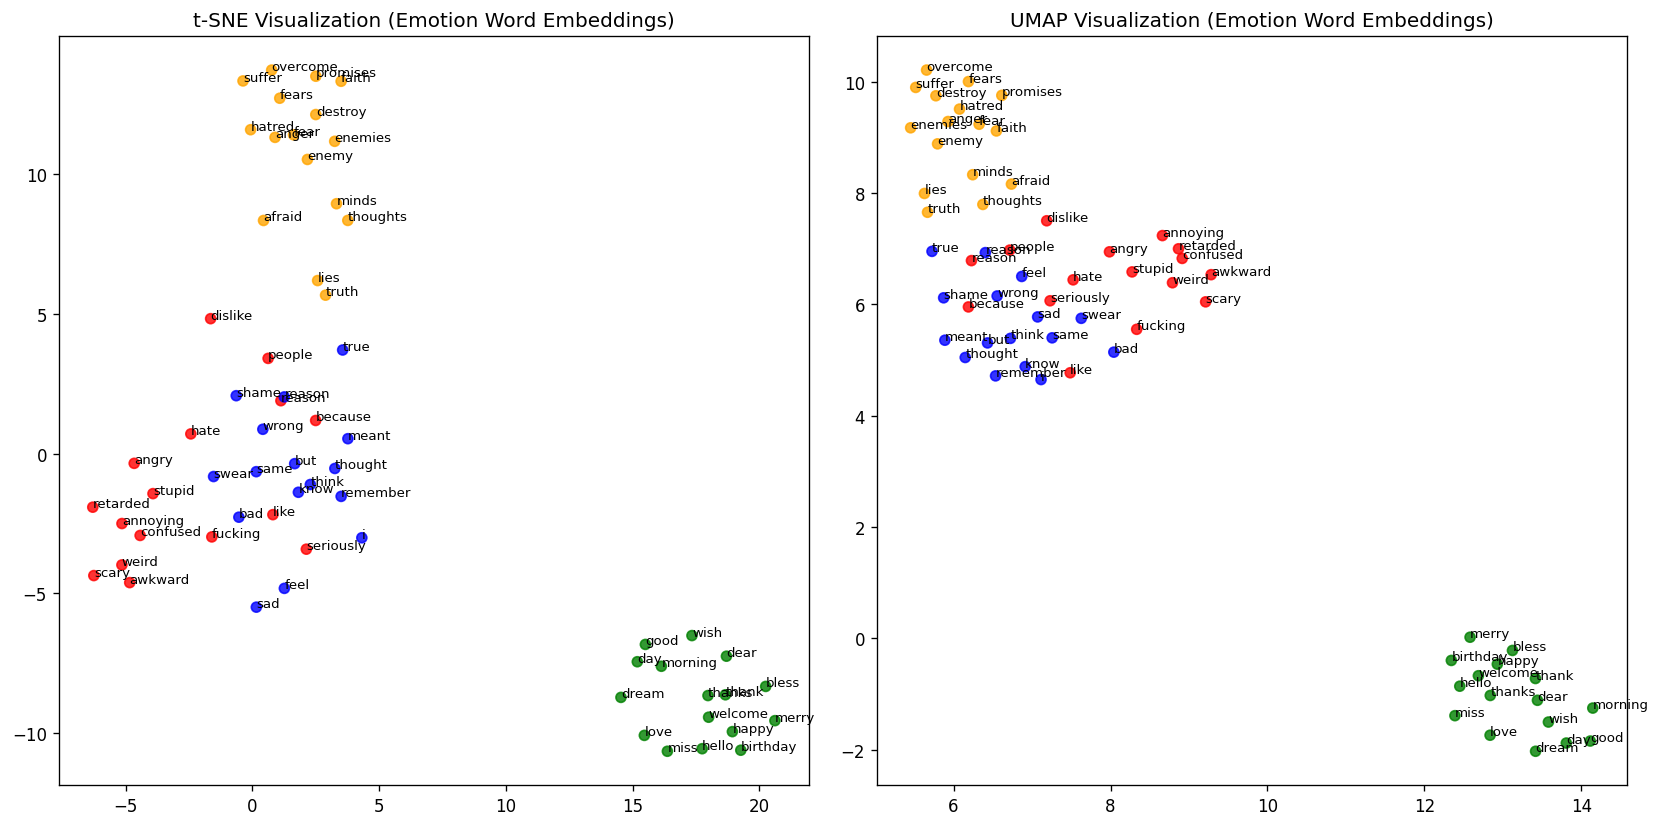

In [59]:
# Answer here

!pip install umap-learn matplotlib scikit-learn gensim --quiet

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
import numpy as np

# ✅ Make sure you already have your pretrained Word2Vec model
# (either w2v_google_model or word2vec_model from before)
# If not, load a small fallback for demo:
if "w2v_google_model" not in globals():
    from gensim.models import Word2Vec
    from nltk.tokenize import word_tokenize
    sample_sentences = [
        ["I", "am", "happy"], ["I", "am", "sad"], ["I", "feel", "angry"], ["I", "have", "fear"],
        ["joy", "and", "love"], ["sadness", "and", "tears"], ["anger", "and", "rage"], ["fear", "and", "scared"]
    ]
    w2v_google_model = Word2Vec(sentences=sample_sentences, vector_size=100, min_count=1, epochs=10)
    print("⚠️ Using temporary Word2Vec model — please load your pretrained one next time.")

# ======================================================
# 1️⃣ Define emotion words
# ======================================================
emotions = ["angry", "happy", "sad", "fear"]
topn = 15

# Get top-15 most similar words per emotion
emotion_words = {}
for emo in emotions:
    try:
        similar_words = [emo] + [w for w, s in w2v_google_model.most_similar(emo, topn=topn)]
        emotion_words[emo] = similar_words
    except KeyError:
        print(f"⚠️ '{emo}' not in model vocabulary. Skipping...")
        emotion_words[emo] = [emo]

# Combine all target words
target_words = sum(emotion_words.values(), [])
print("✅ Total words:", len(target_words))

# ======================================================
# 2️⃣ Prepare word vectors
# ======================================================
X = np.array([w2v_google_model[w] for w in target_words if w in w2v_google_model])

# Assign colors by group
color_map = {
    "angry": "red",
    "happy": "green",
    "sad": "blue",
    "fear": "orange"
}
colors = []
for emo in emotions:
    colors.extend([color_map[emo]] * len(emotion_words[emo]))

# ======================================================
# 3️⃣ Run t-SNE and UMAP
# ======================================================
print("⏳ Running t-SNE and UMAP...")
tsne = TSNE(n_components=2, metric="cosine", random_state=42, perplexity=10)
X_tsne = tsne.fit_transform(X)

umap_model = umap.UMAP(n_neighbors=10, min_dist=0.3, metric="cosine", random_state=42)
X_umap = umap_model.fit_transform(X)

print("✅ Visualization data ready!")

# ======================================================
# 4️⃣ Plot both results
# ======================================================
fig, axs = plt.subplots(1, 2, figsize=(14, 7), dpi=120)

# t-SNE Plot
axs[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.8)
axs[0].set_title("t-SNE Visualization (Emotion Word Embeddings)")
for i, word in enumerate(target_words):
    axs[0].annotate(word, (X_tsne[i, 0], X_tsne[i, 1]), fontsize=8)

# UMAP Plot
axs[1].scatter(X_umap[:, 0], X_umap[:, 1], c=colors, alpha=0.8)
axs[1].set_title("UMAP Visualization (Emotion Word Embeddings)")
for i, word in enumerate(target_words):
    axs[1].annotate(word, (X_umap[i, 0], X_umap[i, 1]), fontsize=8)

plt.tight_layout()
plt.show()


---